# Entregable 2 — Adquisicion y Analisis Exploratorio de Datos (EDA)

## CriticalGraphRAG: Chatbot de analisis del conflicto Israel/Palestina

**Materia:** Machine Learning | **Equipo:** CriticalGraphRAG | **Fecha:** Abril 2026

---

### Objetivo

Construir un chatbot que analice el conflicto armado en Israel/Palestina (2023) combinando un **Knowledge Graph** (Neo4j) con **embeddings vectoriales** y un **agente LLM** (Gemini).

Este entregable cubre la adquisicion, limpieza y analisis exploratorio del dataset ACLED, dejando los datos listos para la construccion del Knowledge Graph.

In [21]:
import subprocess, sys
subprocess.check_call(["poetry", "install", "--with", "notebooks", "-q"], cwd="..")

0

## 1. Descripcion del Dataset

| | |
|---|---|
| **Fuente** | [ACLED](https://acleddata.com/) — Armed Conflict Location & Event Data Project |
| **Adquisicion** | API REST con OAuth2, via `scripts/01_download.py` |
| **Filtros** | Pais = Israel, Año = 2023 (ver `config/dataset_filter.yaml`) |
| **Formato** | CSV — `data/acled_israel_2023.csv` |
| **Filas** | ~4.259 eventos |
| **Columnas** | 31 variables |

**Justificacion:**
1. **Riqueza relacional** — cada evento conecta actores, ubicaciones, tipos y fuentes: ideal para Knowledge Graph.
2. **Texto narrativo** — la columna `notes` habilita busqueda semantica via embeddings.
3. **Calidad** — ACLED es fuente academica reconocida con codificacion estandarizada.

### Variables principales

| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `event_id_cnty` | string | ID unico (ej: ISR13532) |
| `event_date` | date | Fecha del evento |
| `event_type` / `sub_event_type` | cat | Tipo y subtipo de evento |
| `disorder_type` | cat | Categoria de desorden |
| `actor1`, `actor2` | cat | Actores involucrados |
| `assoc_actor_1/2` | cat | Actores asociados (separados por ";") |
| `inter1`, `inter2` | int | Codigo de tipo de actor |
| `admin1/2/3`, `location` | cat | Ubicacion administrativa |
| `latitude`, `longitude` | float | Coordenadas |
| `fatalities` | int | Numero de fatalidades |
| `notes` | text | Descripcion narrativa (campo embeddeable) |
| `source` | cat | Fuentes periodisticas (separadas por ";") |

---
## 2. Análisis Exploratorio Básico

En esta sección analizamos la estructura, calidad y distribución de los datos. Cubrimos tipos de variables, estadísticas descriptivas, valores faltantes, distribuciones y visualizaciones iniciales.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 100})

df = pd.read_csv("../data/acled_israel_2023.csv", low_memory=False)
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["fatalities"] = pd.to_numeric(df["fatalities"], errors="coerce")
df["month"] = df["event_date"].dt.to_period("M")

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 4,259 filas × 32 columnas


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp,month
0,ISR13532,2023-01-01,2023,1,Demonstrations,Protests,Peaceful protest,Protesters (Israel),Students (Israel),Protesters,...,31.6100,34.7642,1,Jerusalem Post,National,"On 1 January 2023, hundreds of students partic...",0,crowd size=hundreds,1759789919,2023-01
1,ISR13534,2023-01-04,2023,1,Strategic developments,Strategic developments,Looting/property destruction,Police Forces of Israel (2022-),NaN,State forces,...,31.2588,35.2128,1,Arab 48,International,"Property destruction: On 4 January 2023, Israe...",0,NaN,1673305337,2023-01
2,ISR13542,2023-01-11,2023,1,Demonstrations,Protests,Peaceful protest,Protesters (Israel),Arab Ethnic Group (Israel); Histadrut Union; L...,Protesters,...,31.2518,34.7913,1,Panet,National,"On 11 January 2023, dozens of Jewish and Israe...",0,crowd size=dozens,1763426427,2023-01
3,ISR13546,2023-01-10,2023,1,Demonstrations,Protests,Peaceful protest,Protesters (Israel),Students (Israel); Yesh Atid,Protesters,...,31.2518,34.7913,1,Arutz Sheva; Ma'ariv; Times of Israel; Walla!N...,National,"On 10 January 2023, dozens of students, many o...",0,crowd size=dozens,1763426427,2023-01
4,ISR13565,2023-01-18,2023,1,Demonstrations,Protests,Peaceful protest,Protesters (Israel),Arab Ethnic Group (Israel); Health Workers (Is...,Protesters,...,31.2518,34.7913,1,Arutz Sheva; Ma'ariv; Mynet; Panet,National,"On 18 January 2023, a group of health workers,...",0,crowd size=no report,1763426427,2023-01


### 2.1 Dimensiones y tipos de dato

In [23]:
stats = pd.DataFrame({
    "Tipo": df.dtypes,
    "No nulos": df.notnull().sum(),
    "Nulos": df.isnull().sum(),
    "% Nulos": (df.isnull().sum() / len(df) * 100).round(1),
    "Únicos": df.nunique(),
})
stats

,Tipo,No nulos,Nulos,% Nulos,Únicos
event_id_cnty,str,4259,0,0.0,4259
event_date,datetime64[us],4259,0,0.0,347
year,int64,4259,0,0.0,1
time_precision,int64,4259,0,0.0,3
disorder_type,str,4259,0,0.0,4
event_type,str,4259,0,0.0,6
sub_event_type,str,4259,0,0.0,19
actor1,str,4259,0,0.0,31
assoc_actor_1,str,1438,2821,66.2,439
inter1,str,4259,0,0.0,6


### 2.2 Estadísticas descriptivas

In [24]:
print("=== Variables numéricas ===\n")
display(df.describe())

print("\n=== Variables categóricas (resumen) ===\n")
display(df.describe(include="object"))

=== Variables numéricas ===



,event_date,year,time_precision,iso,latitude,longitude,geo_precision,fatalities,timestamp
count,4259,4259.0,4259.000000,4259.0,4259.000000,4259.000000,4259.000000,4259.000000,4.259000e+03
mean,2023-07-22 15:41:17.482977,2023.0,1.005400,376.0,32.143669,34.961990,1.258277,0.416295,1.736804e+09
min,2023-01-01 00:00:00,2023.0,1.000000,376.0,29.500000,34.284600,1.000000,0.000000,1.673305e+09
25%,2023-04-15 00:00:00,2023.0,1.000000,376.0,31.769000,34.780600,1.000000,0.000000,1.721086e+09
50%,2023-07-22 00:00:00,2023.0,1.000000,376.0,32.080900,34.893200,1.000000,0.000000,1.736845e+09
75%,2023-10-23 00:00:00,2023.0,1.000000,376.0,32.690400,35.202700,1.000000,0.000000,1.755553e+09
max,2023-12-31 00:00:00,2023.0,3.000000,376.0,33.279200,35.658400,3.000000,377.000000,1.772498e+09
std,NaN,0.0,0.085154,0.0,0.689653,0.302176,0.459720,6.682719,1.958231e+07



=== Variables categóricas (resumen) ===



,event_id_cnty,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,assoc_actor_2,inter2,...,region,country,admin1,admin2,admin3,location,source,source_scale,notes,tags
count,4259,4259,4259,4259,4259,1438,4259,1787,248,1787,...,4259,4259,4259,4258,4245,4259,4259,4259,4259,2571
unique,4259,4,6,19,31,439,6,25,86,6,...,1,1,6,14,45,418,1047,20,4259,207
top,ISR13532,Demonstrations,Protests,Peaceful protest,Protesters (Israel),Kaplan Force,Protesters,Military Forces of Israel (2022-),Arab Ethnic Group (Israel),State forces,...,Middle East,Israel,HaZafon,Tel Aviv,Tel Aviv,Tel Aviv,Haaretz,National,"On 1 January 2023, hundreds of students partic...",crowd size=no report
freq,1,2525,2413,2196,2423,174,2423,606,28,886,...,4259,4259,1037,610,603,315,286,2907,1,1155


### 2.3 Valores faltantes

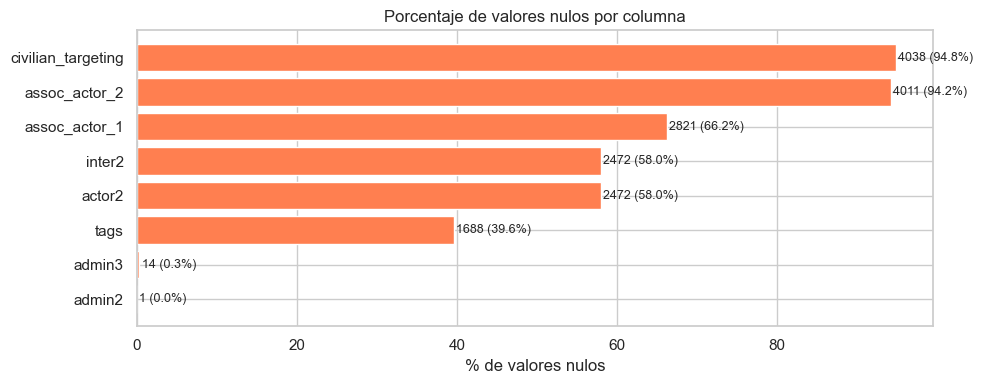

In [25]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
nulls_df = pd.DataFrame({"Nulos": nulls, "%": nulls_pct}).sort_values("%", ascending=True)
nulls_df = nulls_df[nulls_df["Nulos"] > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(nulls_df) * 0.4)))
ax.barh(nulls_df.index, nulls_df["%"], color="coral", edgecolor="white")
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de valores nulos por columna")
for i, (val, pct) in enumerate(zip(nulls_df["Nulos"], nulls_df["%"])):
    ax.text(pct + 0.3, i, f"{val} ({pct}%)", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 2.4 Distribuciones categóricas y cardinalidades

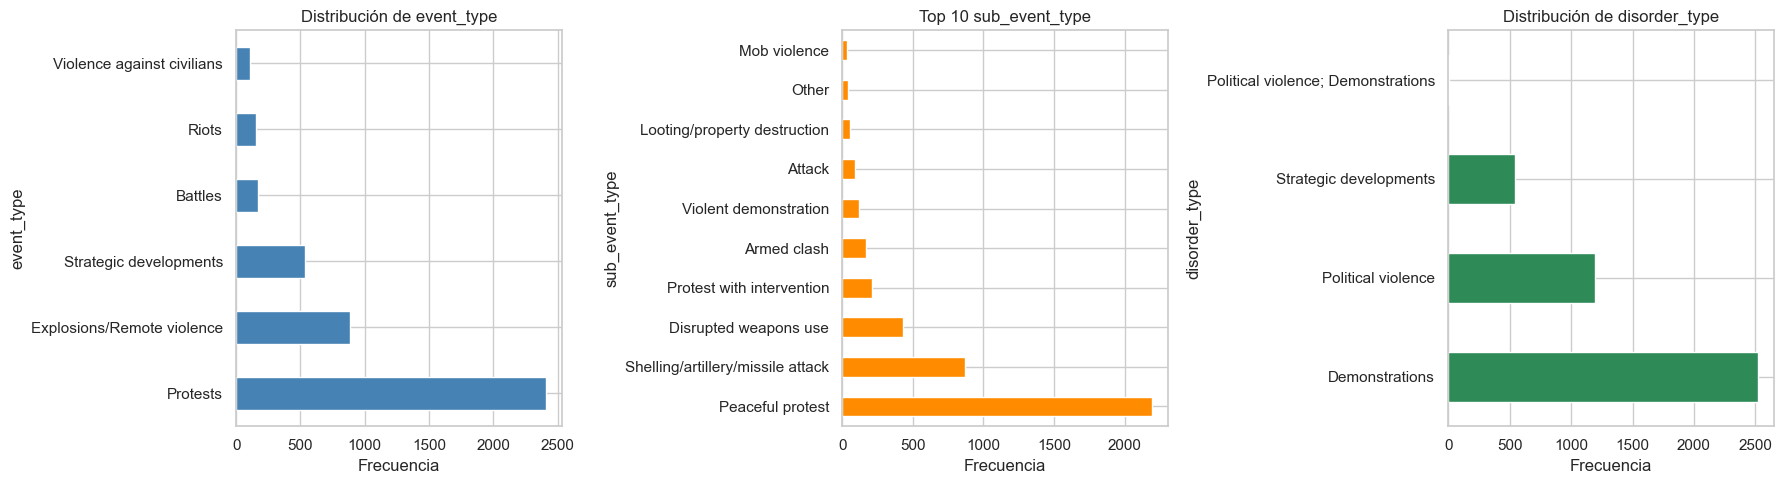


=== Cardinalidades de columnas categóricas ===

                Valores únicos
event_type                   6
sub_event_type              19
disorder_type                4
actor1                      31
actor2                      25
country                      1
admin1                       6
admin2                      14
inter1                       6
inter2                       6
source_scale                20


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# event_type
df["event_type"].value_counts().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de event_type")
axes[0].set_xlabel("Frecuencia")

# sub_event_type (top 10)
df["sub_event_type"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Top 10 sub_event_type")
axes[1].set_xlabel("Frecuencia")

# disorder_type
df["disorder_type"].value_counts().plot(kind="barh", ax=axes[2], color="seagreen", edgecolor="white")
axes[2].set_title("Distribución de disorder_type")
axes[2].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

# Cardinalidades
print("\n=== Cardinalidades de columnas categóricas ===\n")
cat_cols = ["event_type", "sub_event_type", "disorder_type", "actor1", "actor2",
            "country", "admin1", "admin2", "inter1", "inter2", "source_scale"]
card = pd.DataFrame({
    "Valores únicos": {col: df[col].nunique() for col in cat_cols if col in df.columns}
})
print(card.to_string())

### 2.5 Distribución temporal

In [ ]:
daily = df.groupby("event_date").size()
monthly = df.groupby("month").size()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Serie diaria
axes[0].fill_between(daily.index, daily.values, alpha=0.4, color="steelblue")
axes[0].plot(daily.index, daily.values, linewidth=0.8, color="steelblue")
axes[0].axvline(x=pd.Timestamp("2023-10-07"), color="red", ls="--", lw=2, label="7 Oct — Ataque de Hamas")
axes[0].set_title("Eventos por día")
axes[0].set_ylabel("Eventos")
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# Barras mensuales
monthly.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
oct_idx = list(monthly.index).index(pd.Period("2023-10", "M"))
axes[1].axvline(x=oct_idx, color="red", ls="--", lw=2, label="Oct")
axes[1].set_title("Eventos por mes")
axes[1].set_ylabel("Eventos")
axes[1].set_xticklabels([str(m) for m in monthly.index], rotation=45, ha="right")
axes[1].legend()

plt.tight_layout()
plt.show()

pre = monthly[monthly.index < pd.Period("2023-10", "M")].sum()
post = monthly[monthly.index >= pd.Period("2023-10", "M")].sum()
print(f"Pre-octubre: {pre:,}  |  Oct-Dic: {post:,}  |  Ratio: {post/pre:.1f}x")

In [ ]:
fat_monthly = df.groupby("month")["fatalities"].sum()
months_str = [str(m) for m in fat_monthly.index]

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["crimson" if m >= pd.Period("2023-10", "M") else "steelblue" for m in fat_monthly.index]
ax.bar(months_str, fat_monthly.values, color=colors, edgecolor="white", width=0.7)
ax.set_title("Fatalidades por mes (2023)", fontsize=14)
ax.set_ylabel("Fatalidades")
ax.set_xlabel("Mes")

# Etiquetas sobre cada barra
for i, v in enumerate(fat_monthly.values):
    ax.text(i, v + max(fat_monthly.values) * 0.02, f"{int(v):,}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, fat_monthly.max() * 1.12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fat_pre = fat_monthly[fat_monthly.index < pd.Period("2023-10", "M")].sum()
fat_post = fat_monthly[fat_monthly.index >= pd.Period("2023-10", "M")].sum()
print(f"Fatalidades pre-oct: {fat_pre:,.0f}  |  Oct-Dic: {fat_post:,.0f}  |  Ratio: {fat_post/max(fat_pre,1):.1f}x")

### 2.6 Composición de tipos de evento (pre vs post 7 de octubre)

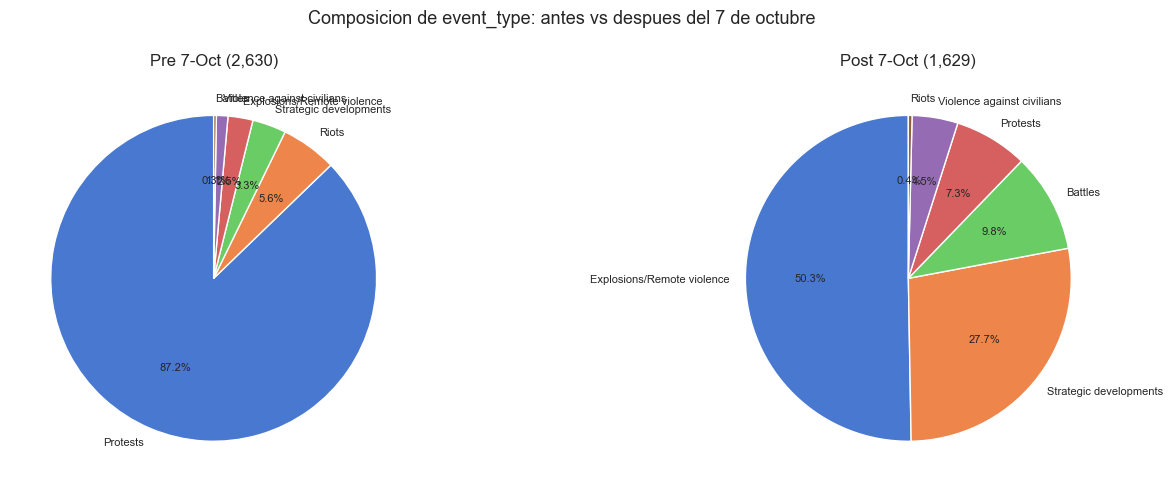

In [28]:
pre_oct = df[df["event_date"] < "2023-10-07"]
post_oct = df[df["event_date"] >= "2023-10-07"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset, title in [(axes[0], pre_oct, f"Pre 7-Oct ({len(pre_oct):,})"),
                           (axes[1], post_oct, f"Post 7-Oct ({len(post_oct):,})")]:
    subset["event_type"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%",
                                              startangle=90, textprops={"fontsize": 8})
    ax.set_title(title)
    ax.set_ylabel("")

plt.suptitle("Composicion de event_type: antes vs despues del 7 de octubre", fontsize=13)
plt.tight_layout()
plt.show()

### 2.7 Actores, fatalidades y geografía

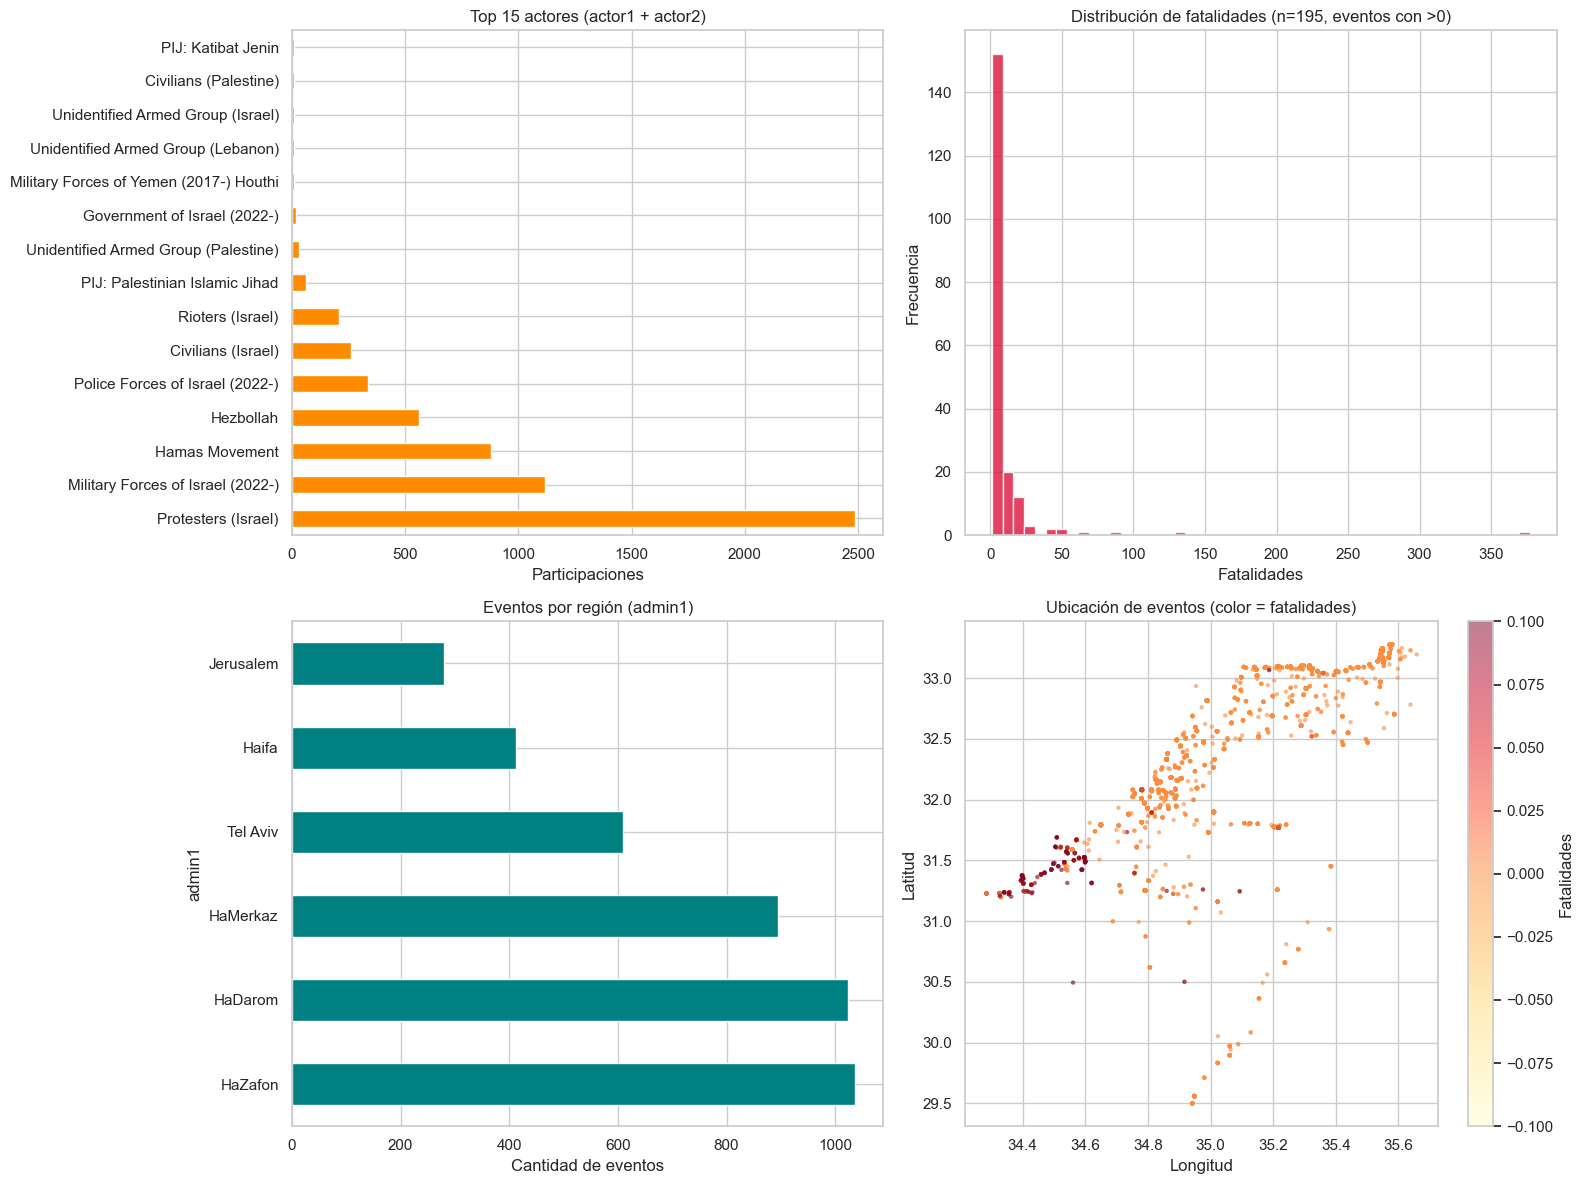


=== Estadísticas de fatalidades ===

  Total:                  1,773
  Media:                  0.42
  Mediana:                0.0
  Máximo:                 377
  Eventos con fat. > 0:  195 (4.6%)


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 15 actores
actors = pd.concat([
    df["actor1"].dropna().loc[df["actor1"].str.strip() != ""],
    df["actor2"].dropna().loc[df["actor2"].str.strip() != ""]
])
actors.value_counts().head(15).plot(kind="barh", ax=axes[0, 0], color="darkorange", edgecolor="white")
axes[0, 0].set_title("Top 15 actores (actor1 + actor2)")
axes[0, 0].set_xlabel("Participaciones")

# Fatalidades - histograma
fat_nonzero = df.loc[df["fatalities"] > 0, "fatalities"]
axes[0, 1].hist(fat_nonzero, bins=50, color="crimson", edgecolor="white", alpha=0.8)
axes[0, 1].set_title(f"Distribución de fatalidades (n={len(fat_nonzero)}, eventos con >0)")
axes[0, 1].set_xlabel("Fatalidades")
axes[0, 1].set_ylabel("Frecuencia")

# Distribución geográfica (admin1)
df["admin1"].value_counts().plot(kind="barh", ax=axes[1, 0], color="teal", edgecolor="white")
axes[1, 0].set_title("Eventos por región (admin1)")
axes[1, 0].set_xlabel("Cantidad de eventos")

# Scatter geográfico
scatter = axes[1, 1].scatter(df["longitude"], df["latitude"],
                              c=df["fatalities"], cmap="YlOrRd", s=5, alpha=0.5,
                              vmin=0, vmax=df["fatalities"].quantile(0.95))
axes[1, 1].set_title("Ubicación de eventos (color = fatalidades)")
axes[1, 1].set_xlabel("Longitud")
axes[1, 1].set_ylabel("Latitud")
plt.colorbar(scatter, ax=axes[1, 1], label="Fatalidades")

plt.tight_layout()
plt.show()

# Estadísticas de fatalidades
print("\n=== Estadísticas de fatalidades ===\n")
fat = df["fatalities"]
print(f"  Total:                  {fat.sum():,.0f}")
print(f"  Media:                  {fat.mean():.2f}")
print(f"  Mediana:                {fat.median():.1f}")
print(f"  Máximo:                 {fat.max():.0f}")
print(f"  Eventos con fat. > 0:  {(fat > 0).sum()} ({(fat > 0).mean()*100:.1f}%)")

---
## 3. Diagnóstico y mejoras en la calidad de los datos

=== Diagnóstico de calidad ===

  IDs duplicados (event_id_cnty)           OK
  Filas completamente duplicadas           OK
  Año != 2023                              OK
  País != Israel                           OK
  Fatalidades negativas                    OK
  year != event_date.year                  OK
  notes vacíos/nulos                       OK

=== Valores vacíos (ausencia semántica, no error) ===


=== Outliers en fatalidades (>0, IQR): 195 eventos ===

event_id_cnty event_date                 event_type  fatalities               location
     ISR37331 2023-10-07 Violence against civilians         377   Nova Festival - Reim
     ISR16296 2023-10-07                    Battles         129                  Beeri
     ISR45135 2023-10-07 Violence against civilians          91                  Beeri
     ISR16346 2023-10-07                    Battles          65 Nahal Oz Military Base
     ISR37321 2023-10-07 Violence against civilians          51             Kefar Azza


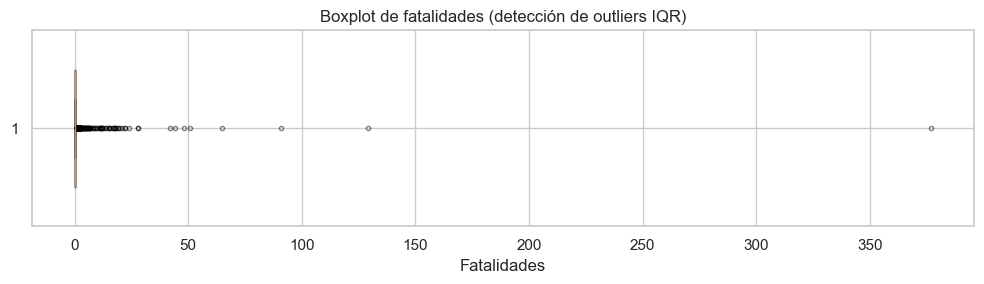

In [30]:
print("=== Diagnóstico de calidad ===\n")

checks = {
    "IDs duplicados (event_id_cnty)": df["event_id_cnty"].duplicated().sum(),
    "Filas completamente duplicadas": df.duplicated().sum(),
    "Año != 2023": (df["event_date"].dt.year != 2023).sum(),
    "País != Israel": (df["country"] != "Israel").sum(),
    "Fatalidades negativas": (df["fatalities"] < 0).sum(),
    "year != event_date.year": (df["event_date"].dt.year != df["year"]).sum(),
    "notes vacíos/nulos": df["notes"].isnull().sum() + (df["notes"].str.strip() == "").sum(),
}

for check, count in checks.items():
    status = "OK" if count == 0 else f"ALERTA ({count})"
    print(f"  {check:<40} {status}")

# Valores vacíos semánticos
print("\n=== Valores vacíos (ausencia semántica, no error) ===\n")
text_cols = df.select_dtypes(include="object").columns
empty = {col: (df[col].str.strip() == "").sum() for col in text_cols}
for col, n in sorted(empty.items(), key=lambda x: -x[1]):
    if n > 0:
        print(f"  {col:<25} {n:>5} ({n/len(df)*100:.1f}%)")

# Outliers fatalidades (IQR)
Q1, Q3 = df["fatalities"].quantile(0.25), df["fatalities"].quantile(0.75)
upper = Q3 + 1.5 * (Q3 - Q1)
n_outliers = (df["fatalities"] > upper).sum()
print(f"\n=== Outliers en fatalidades (>{upper:.0f}, IQR): {n_outliers} eventos ===\n")
if n_outliers > 0:
    print(df.nlargest(5, "fatalities")[["event_id_cnty", "event_date", "event_type", "fatalities", "location"]].to_string(index=False))

# Boxplot de fatalidades
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(df["fatalities"].dropna(), vert=False, widths=0.6,
           flierprops=dict(marker="o", markersize=3, alpha=0.5))
ax.set_xlabel("Fatalidades")
ax.set_title("Boxplot de fatalidades (detección de outliers IQR)")
plt.tight_layout()
plt.show()

**Sobre los valores vacios:** En ACLED no son errores sino ausencia semantica — `actor2` vacio = evento unilateral, `admin3` vacio = sin detalle a ese nivel, `civilian_targeting` vacio = no aplica. El pipeline de construccion del Knowledge Graph (`scripts/03_build_graph.py`) ya los maneja correctamente: omite nodos/relaciones cuando el campo esta vacio.

---
## 4. Transformaciones realizadas

Las transformaciones del CSV crudo a la estructura del Knowledge Graph se realizan en `scripts/03_build_graph.py`, guiadas por el contrato `config/graph_schema.yaml`. Veamos el resultado:

In [31]:
import pyarrow.parquet as pq
from pathlib import Path

graph_dir = Path("../data/graph")

print("=== Nodos generados (data/graph/nodes/) ===\n")
for f in sorted((graph_dir / "nodes").glob("*.parquet")):
    tbl = pq.read_table(f)
    print(f"  {f.stem:<20} {tbl.num_rows:>6} filas, {tbl.num_columns} cols  {tbl.column_names}")

print("\n=== Relaciones generadas (data/graph/relationships/) ===\n")
for f in sorted((graph_dir / "relationships").glob("*.parquet")):
    tbl = pq.read_table(f)
    print(f"  {f.stem:<20} {tbl.num_rows:>6} filas, {tbl.num_columns} cols  {tbl.column_names}")

=== Nodos generados (data/graph/nodes/) ===

  Actor                   139 filas, 1 cols  ['actor_name']
  ActorType                 6 filas, 2 cols  ['name', 'specificity_level']
  DisorderType              3 filas, 1 cols  ['name']
  Event                  4259 filas, 8 cols  ['event_id', 'event_date', 'year', 'month', 'day', 'notes', 'fatalities', 'time_precision']
  EventType                25 filas, 3 cols  ['name', 'level', 'specificity_level']
  Location                418 filas, 8 cols  ['country', 'admin1', 'admin2', 'admin3', 'location_name', 'latitude', 'longitude', 'geo_precision']
  Month                    12 filas, 3 cols  ['month_id', 'year', 'month']
  Source                  272 filas, 2 cols  ['source', 'source_scale']

=== Relaciones generadas (data/graph/relationships/) ===

  AT_LOCATION            4259 filas, 3 cols  ['from_event_id', 'to_latitude', 'to_longitude']
  HAS_TYPE                 40 filas, 2 cols  ['from_actor_name', 'to_actor_type_name']
  INVOLVED_I

**Transformaciones aplicadas por el pipeline (`scripts/03_build_graph.py`):**

| Transformacion | Detalle |
|----------------|---------|
| **Derivacion temporal** | `event_date` → nodo `Month` con `month_id` (YYYY-MM) |
| **Deduplicacion de entidades** | Actores por nombre, Locations por (lat, lon), Sources por (source, scale) |
| **Split de campos multi-valor** | `source`, `assoc_actor_1/2`, `disorder_type` se separan por ";" |
| **Codificacion de tipos** | `inter1/2` → nodos `ActorType` con label legible |
| **Jerarquia de eventos** | `event_type` (primary) ← `SUBTYPE_OF` ← `sub_event_type` (sub) |
| **Campos vacios** | Se omiten (no generan nodos ni relaciones) |

No se aplica normalizacion ni estandarizacion porque los datos alimentan un Knowledge Graph, no un modelo numerico. La unica variable numerica (`fatalities`) se mantiene en su escala original como propiedad del nodo `Event`.

---
## 5. Reflexión final

### Decisiones tomadas
- **No se eliminaron outliers de fatalidades:** Son eventos reales del conflicto (ej: ataque del 7 de octubre). Eliminarlos distorsionaría el grafo.
- **No se imputaron campos vacíos:** Representan ausencia semántica, no datos faltantes. El pipeline los maneja por diseño.
- **Embedding solo sobre `notes`:** Es el único campo con texto narrativo rico. El resto de la información se navega por relaciones del grafo.
- **Deduplicación por clave natural:** Actores por nombre, Locations por coordenadas, Sources por (nombre, escala). Esto evita nodos duplicados sin perder información.

### Dificultades encontradas
- Campos multi-valor separados por ";" (`source`, `assoc_actor_*`, `disorder_type`) requieren split y limpieza antes de generar nodos.
- La concentración temporal post-octubre genera un dataset desbalanceado (~75% de eventos en 3 meses). Esto es inherente al dominio.
- Algunos actores aparecen con variaciones menores de nombre en ACLED; la deduplicación por nombre exacto puede dejar duplicados semánticos.

### Siguientes pasos
1. **Embeddings** — Calcular vectores de `Event.notes` con Gemini (`scripts/04_embeddings.py`)
2. **Carga a Neo4j** — Importar nodos, relaciones e índice vectorial (`scripts/05_load_neo4j.py`)
3. **Agente LLM** — Implementar el agente con 3 tools: `cypher_query`, `similarity_search`, `text2cypher`
4. **Evaluación** — Validar con las 50 preguntas de `tests/cgrag_evaluation_questions.csv`